<a href="https://colab.research.google.com/github/CarlosWinicius/Analise-do-Remanejamento-UPE-CARUARU/blob/main/Analise_do_Remanejamento_UPE_CARUARU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import io

print()
uploaded = files.upload()

# Carregar o arquivo para um DataFrame
nome_arquivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nome_arquivo]))

print(f"\n✓ Arquivo '{nome_arquivo}' carregado com sucesso!")
print(f"Total de registros: {len(df)}")


Saving base oficial - base de dados tratada - base de dados tratada (1) (1).csv to base oficial - base de dados tratada - base de dados tratada (1) (1).csv

✓ Arquivo 'base oficial - base de dados tratada - base de dados tratada (1) (1).csv' carregado com sucesso!
Total de registros: 3285


LIMPEZA DOS DADOS E PADRONIZAÇÃO

In [ ]:
# 1. Remover espaços extras nos nomes das colunas
df.columns = df.columns.str.strip()

# 2. Padronizar a coluna 'Entrada' (Garantir SISU e SSA limpos)
df['Entrada'] = df['Entrada'].str.strip().str.upper()

# 3. Criar Modalidade Simplificada (Ampla ou Cotista)
# Usando a coluna 'Categoria_Modalidade' que já parece estar bem definida
df['Modalidade_Simples'] = df['Categoria_Modalidade'].apply(
    lambda x: 'Cotista' if 'Cotista' in str(x) else 'Ampla'
)

# 4. Garantir que 'Ano' seja inteiro
df['Ano'] = pd.to_numeric(df['Ano'], errors='coerce').fillna(0).astype(int)

# 5. Filtrar apenas os Remanejáveis para esta análise
# O status na sua base é 'REMANEJÁVEL'
df_rem = df[df['Status_Resultado'] == 'REMANEJÁVEL'].copy()

print("\n✓ Limpeza da nova base concluída!")
print(f"Total de candidatos remanejáveis encontrados: {len(df_rem)}")


✓ Limpeza da nova base concluída!
Total de candidatos remanejáveis encontrados: 2052


In [ ]:
import matplotlib.pyplot as plt

# ====== CORES FIXAS ======
CORES_ENTRADA = {"SISU": "#1f77b4", "SSA": "#ff7f0e"}               # azul / laranja
CORES_MODALIDADE = {"Ampla": "#2ecc71", "Cotista": "#f1c40f"}      # verde / amarelo

# Cor do "tipo" do gráfico (Geral / cursos) -> SEM ROXO
CORES_TIPO = {
    "Geral": "#2c3e50",                  # azul petróleo
    "ADMINISTRACAO": "#6c5ce7",
    "SISTEMA DE INFORMACAO": "#c0392b"   # vermelho
}

CURSOS_PADRAO = ("ADMINISTRACAO", "SISTEMA DE INFORMACAO")


# ====== HELPERS ======
def _bar_label(ax, padding=2):
    for container in ax.containers:
        ax.bar_label(container, padding=padding)

def _formatar_eixo_x(ax):
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", alpha=0.25)

def _checar_vazio(dados, msg="Atenção: Não há dados para plotar."):
    if dados is None or len(dados) == 0:
        print(msg)
        return True
    return False

def _cor_por_rotulo(rotulo: str) -> str:
    return CORES_TIPO.get(rotulo, "#7f8c8d")

def filtrar_por_curso(dados, curso: str | None):
    if curso is None:
        return dados, "Geral"

    curso_norm = str(curso).strip().upper()
    sub = dados[dados["Curso"].str.strip().str.upper() == curso_norm].copy()
    return sub, curso_norm


# =========================
# GRÁFICO 1 — TOTAL POR ANO (GERAL ou POR CURSO)
# =========================
def grafico_total_por_ano(dados, curso=None):
    sub, rotulo = filtrar_por_curso(dados, curso)
    if _checar_vazio(sub, f"Sem dados para plotar (rotulo={rotulo})."):
        return

    s = sub.groupby("Ano").size().sort_index()
    cor = _cor_por_rotulo(rotulo)

    fig, ax = plt.subplots(figsize=(8, 5))
    s.plot(kind="bar", ax=ax, color=cor, edgecolor="black")

    ax.set_title(f"Total de Remanejáveis por Ano — {rotulo}", fontweight="bold")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Quantidade de candidatos")

    _bar_label(ax, padding=2)
    _formatar_eixo_x(ax)
    plt.tight_layout()
    plt.show()


# =========================
# GRÁFICO 2 — POR ENTRADA (GERAL ou POR CURSO)
# =========================
def grafico_por_entrada(dados, curso=None):
    sub, rotulo = filtrar_por_curso(dados, curso)
    if _checar_vazio(sub, f"Sem dados para plotar (rotulo={rotulo})."):
        return

    tabela = (
        sub.groupby(["Ano", "Entrada"])
           .size()
           .unstack(fill_value=0)
           .sort_index()
    )

    # ordem fixa (SISU, SSA)
    cols = [c for c in ["SISU", "SSA"] if c in tabela.columns] + [c for c in tabela.columns if c not in ["SISU", "SSA"]]
    tabela = tabela[cols]

    cores = [CORES_ENTRADA.get(c, "#7f7f7f") for c in tabela.columns]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_facecolor(plt.matplotlib.colors.to_rgba(_cor_por_rotulo(rotulo), 0.06))

    tabela.plot(kind="bar", ax=ax, color=cores, edgecolor="black")

    ax.set_title(f"Remanejáveis por Entrada (SISU x SSA) — {rotulo}", fontweight="bold")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Quantidade de candidatos")
    ax.legend(title="Entrada")

    _bar_label(ax, padding=2)
    _formatar_eixo_x(ax)
    plt.tight_layout()
    plt.show()


# =========================
# GRÁFICO 3 — POR MODALIDADE (VERSÃO BOA: 100% EMPILHADO)
# =========================
def grafico_por_modalidade(dados, curso=None, modo="percentual"):
    """
    modo:
      - "percentual": barras empilhadas 100% (mais legível)
      - "contagem": empilhado em contagem
    """
    sub, rotulo = filtrar_por_curso(dados, curso)
    if _checar_vazio(sub, f"Sem dados para plotar (rotulo={rotulo})."):
        return

    tabela = (
        sub.groupby(["Ano", "Modalidade_Simples"])
           .size()
           .unstack(fill_value=0)
           .sort_index()
    )

    # ordem fixa (Ampla, Cotista)
    cols = [c for c in ["Ampla", "Cotista"] if c in tabela.columns] + [c for c in tabela.columns if c not in ["Ampla", "Cotista"]]
    tabela = tabela[cols]

    if modo == "percentual":
        tabela_plot = (tabela.div(tabela.sum(axis=1), axis=0) * 100).round(1)
        ylabel = "Percentual (%)"
        titulo_extra = " (Distribuição %)"
    else:
        tabela_plot = tabela
        ylabel = "Quantidade de candidatos"
        titulo_extra = " (Contagem)"

    cores = [CORES_MODALIDADE.get(c, "#95a5a6") for c in tabela_plot.columns]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor(plt.matplotlib.colors.to_rgba(_cor_por_rotulo(rotulo), 0.06))

    tabela_plot.plot(kind="bar", stacked=True, ax=ax, color=cores, edgecolor="black", linewidth=0.4)

    ax.set_title(f"Remanejáveis por Modalidade{titulo_extra} — {rotulo}", fontweight="bold")
    ax.set_xlabel("Ano")
    ax.set_ylabel(ylabel)
    ax.legend(title="Modalidade", ncols=2, loc="upper left", bbox_to_anchor=(0, 1.12))

    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()


# =========================
# SEÇÕES (pra rodar só o que você quer)
# =========================
def secao_total(df_rem, cursos=CURSOS_PADRAO):
    print("=== SEÇÃO: TOTAL POR ANO ===")
    grafico_total_por_ano(df_rem, curso=None)
    for c in cursos:
        grafico_total_por_ano(df_rem, curso=c)
0
def secao_entrada(df_rem, cursos=CURSOS_PADRAO):
    print("=== SEÇÃO: POR ENTRADA (SISU x SSA) ===")
    grafico_por_entrada(df_rem, curso=None)
    for c in cursos:
        grafico_por_entrada(df_rem, curso=c)

def grafico_por_modalidade(dados, curso=None):
    sub, rotulo = filtrar_por_curso(dados, curso)
    if _checar_vazio(sub, f"Sem dados para plotar (rotulo={rotulo})."):
        return

    # Contagem por ano e modalidade (Ampla/Cotista)
    base = (
        sub.groupby(["Ano", "Modalidade_Simples"])
           .size()
           .unstack(fill_value=0)
           .sort_index()
    )

    # Garante que as colunas existam
    for col in ["Ampla", "Cotista"]:
        if col not in base.columns:
            base[col] = 0

    # Cria TOTAL
    base["Total"] = base["Ampla"] + base["Cotista"]

    # Reordena: Total, Cotista, Ampla (3 barras)
    tabela = base[["Ampla", "Cotista",]]

    # Cores fixas (sem roxo)
    cores = {
        "Total": "#2C3E50",  # cor muda por Geral/ADM/SI
        "Cotista":"#f1c40f",               # amarelo
        "Ampla":  "#2ecc71"                # verde
    }

    fig, ax = plt.subplots(figsize=(10, 5))
    tabela.plot(
        kind="bar",
        ax=ax,
        color=[cores[c] for c in tabela.columns],
        edgecolor="black"
    )

    ax.set_title(f"Remanejáveis por Modalidade — {rotulo}", fontweight="bold")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Quantidade de candidatos")
    ax.legend(title="Modalidade")

    for container in ax.containers:
        ax.bar_label(container, padding=2)

    _formatar_eixo_x(ax)
    plt.tight_layout()
    plt.show()


=== SEÇÃO: TOTAL POR ANO ===


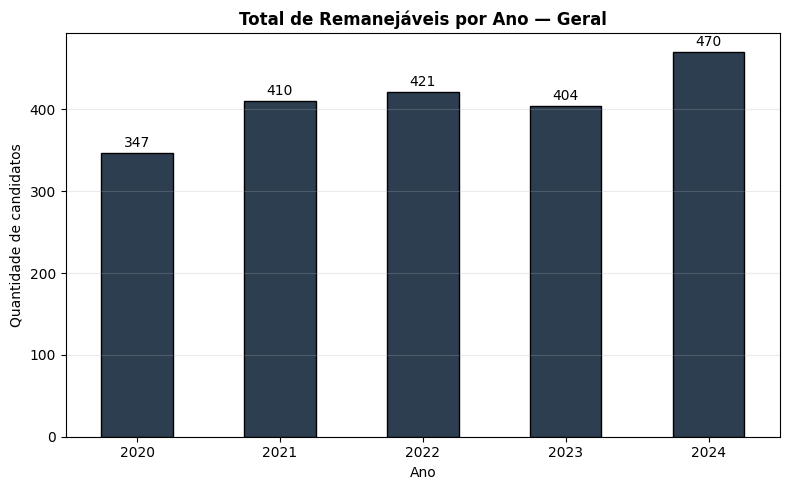

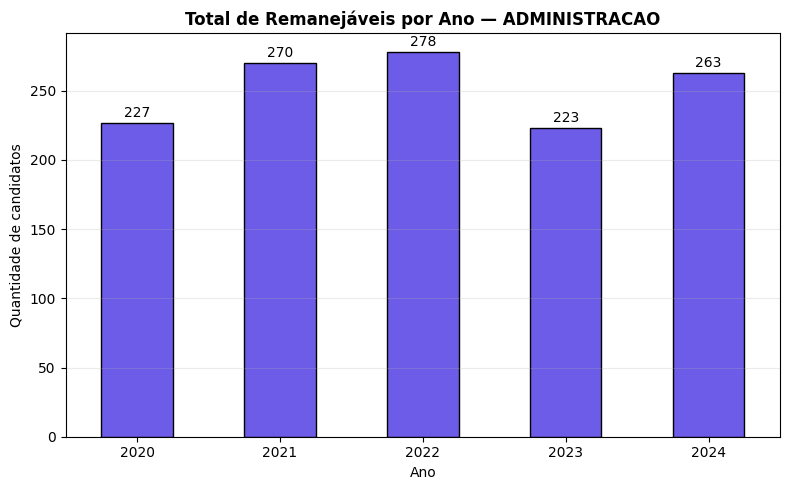

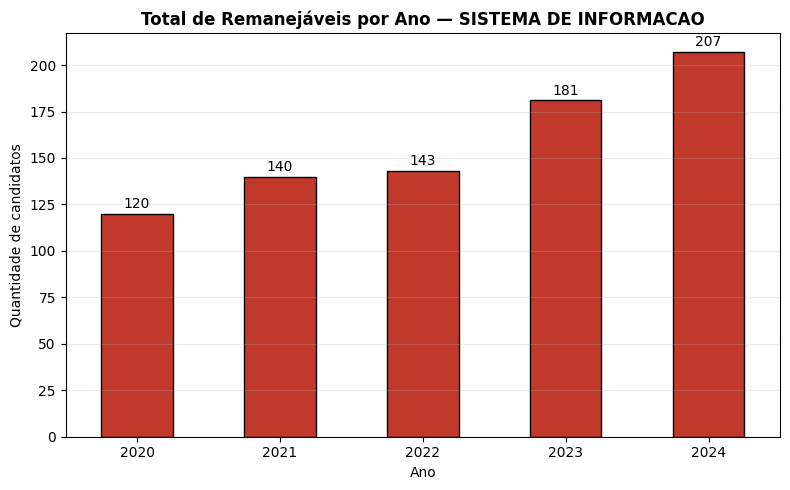

In [ ]:
secao_total(df_rem)


Por Entrada

=== SEÇÃO: POR ENTRADA (SISU x SSA) ===


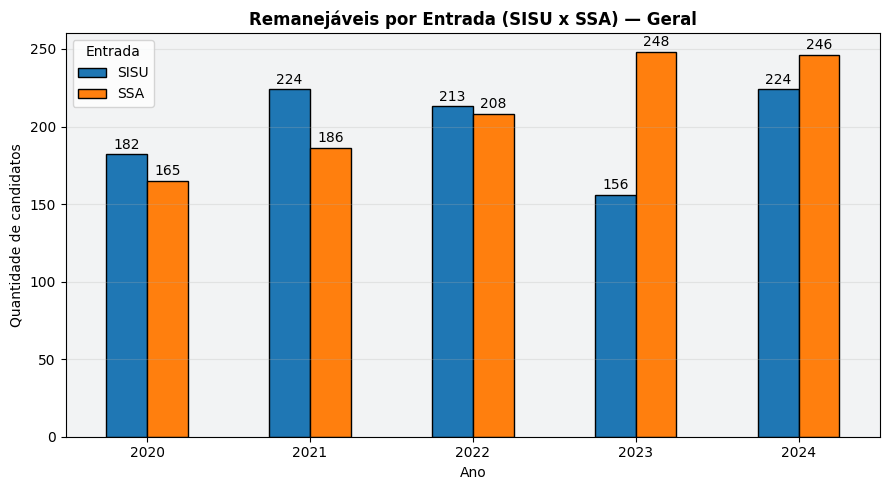

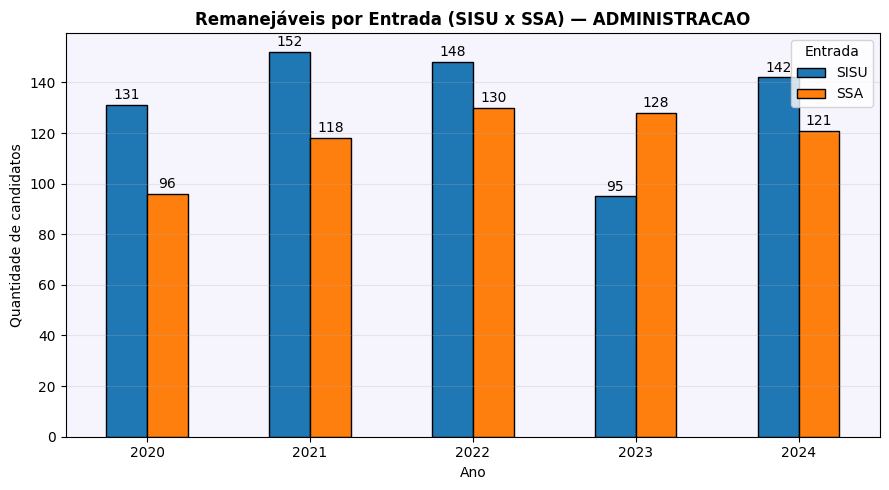

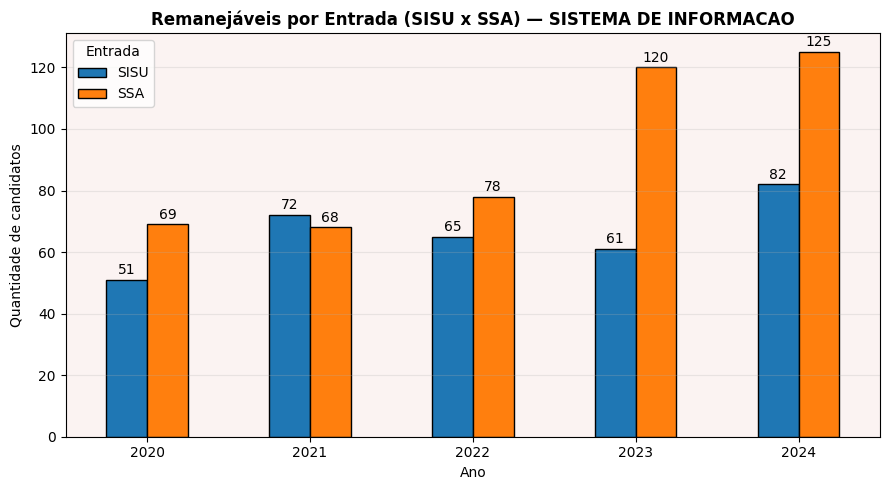

In [ ]:
secao_entrada(df_rem)

SEÇÃO POR MADALIDADE

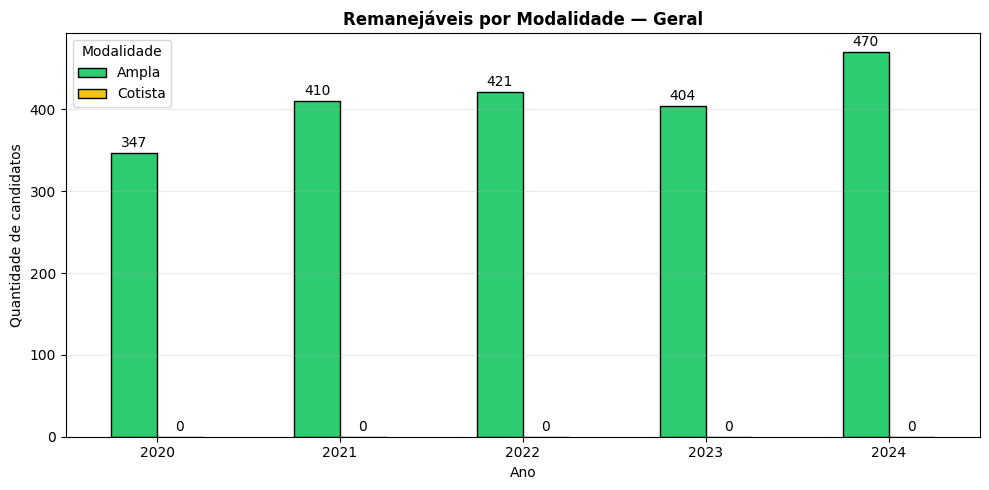

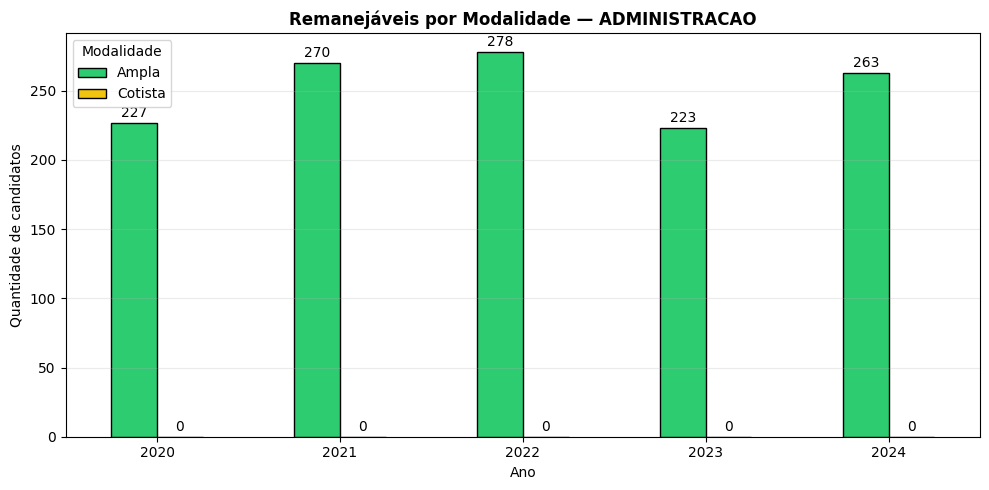

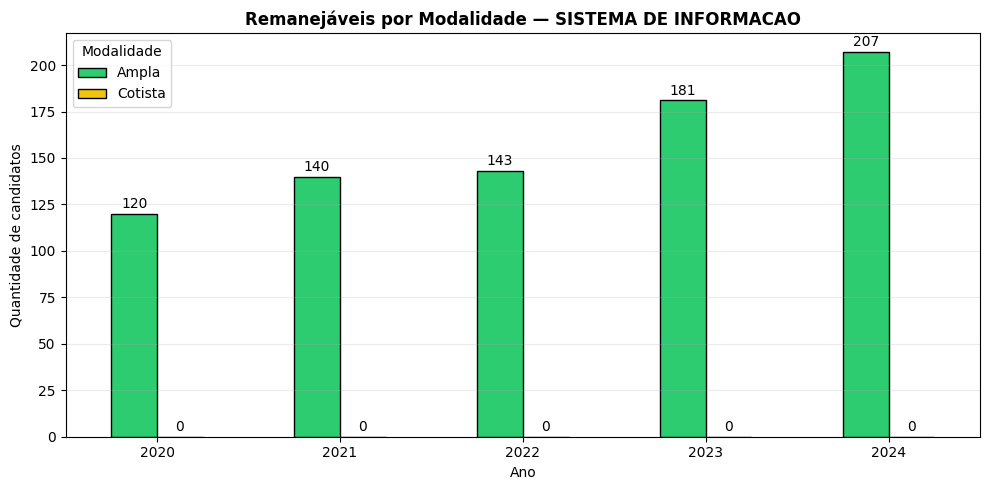

In [ ]:
# Geral
grafico_por_modalidade(df_rem)

# Administração
grafico_por_modalidade(df_rem, curso="ADMINISTRACAO")

# Sistema de Informação
grafico_por_modalidade(df_rem, curso="SISTEMA DE INFORMACAO")


In [ ]:
# Padronizar Status (evitar problema com acento)
df['Status_Resultado'] = (
    df['Status_Resultado']
    .astype(str)
    .str.strip()
    .str.upper()
)

# Dataframe correto: APENAS os convocados
df_chamados = df[df['Status_Resultado'] == 'REMANEJADOS'].copy()

print("Total de candidatos convocados por remanejamento:", len(df_chamados))


Total de candidatos convocados por remanejamento: 783


Remanejados

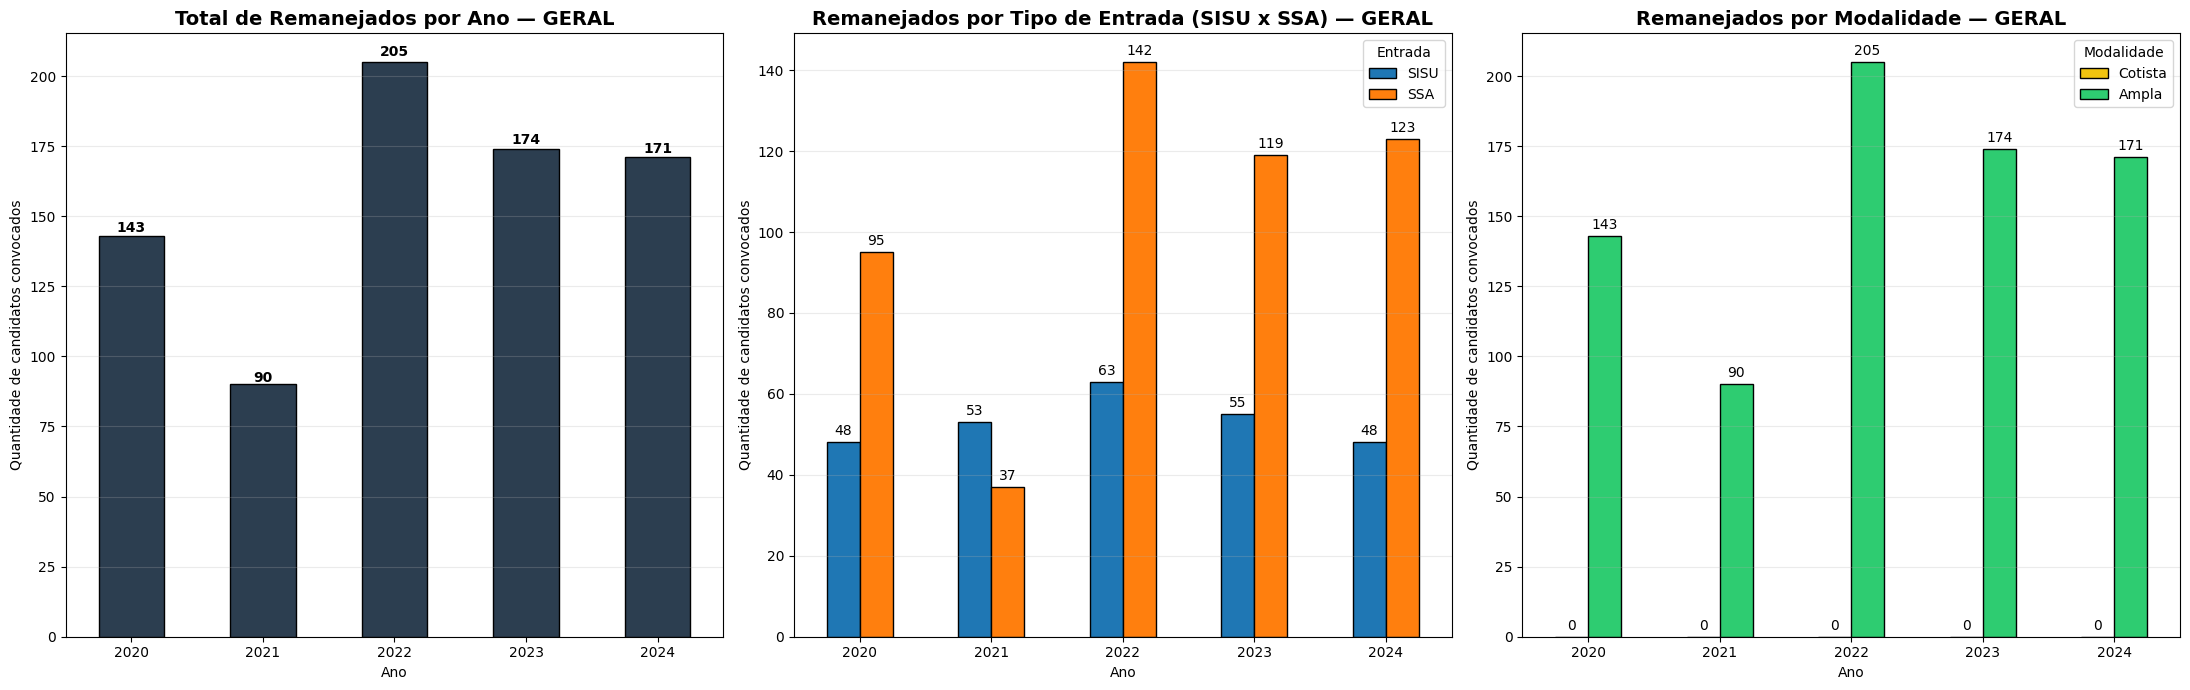

In [ ]:
import matplotlib.pyplot as plt

# =========================
# CORES FIXAS (SEM PALETAS AUTOMÁTICAS)
# =========================
CORES_ENTRADA = {"SISU": "#1f77b4", "SSA": "#ff7f0e"}  # azul / laranja

# Modalidade (sem roxo)
CORES_MODAL = {"Ampla": "#2ecc71", "Cotista": "#f1c40f"}  # verde / amarelo

# Cor do gráfico TOTAL muda por contexto (Geral/ADM/SI)
CORES_CONTEXTO = {
    "GERAL": "#2c3e50",                  # azul petróleo
    "ADMINISTRACAO": "#6c5ce7",
    "SISTEMA DE INFORMACAO": "#c0392b",  # vermelho
}

CURSOS_PADRAO = ("ADMINISTRACAO", "SISTEMA DE INFORMACAO")


def gerar_graficos_remanejamentos(dados, curso=None):
    """
    Gera 3 gráficos (Remanejados/Chamados):
      1) Total por ano
      2) Por entrada (SISU x SSA) com cores fixas
      3) Por modalidade com 3 barras: Total, Cotista, Ampla

    curso:
      - None -> geral
      - "ADMINISTRACAO" / "SISTEMA DE INFORMACAO" -> filtra por curso
    """
    df = dados.copy()

    # padronizações mínimas (pra evitar sujeira de texto)
    df.columns = df.columns.str.strip()
    df["Status_Resultado"] = df["Status_Resultado"].astype(str).str.strip().str.upper()
    df["Entrada"] = df["Entrada"].astype(str).str.strip().str.upper()
    df["Curso"] = df["Curso"].astype(str).str.strip().str.upper()
    df["Modalidade_Simples"] = df["Modalidade_Simples"].astype(str).str.strip()

    # Filtrar apenas REMANEJADOS (convocados)
    df_rem = df[df["Status_Resultado"] == "REMANEJADOS"].copy()

    # Filtrar por curso, se solicitado
    rotulo = "GERAL" if curso is None else str(curso).strip().upper()
    if curso is not None:
        df_rem = df_rem[df_rem["Curso"] == rotulo].copy()

    if df_rem.empty:
        print(f"Atenção: Não foram encontrados dados de REMANEJADOS para {rotulo}.")
        return

    cor_contexto = CORES_CONTEXTO.get(rotulo, CORES_CONTEXTO["GERAL"])

    # Criar figura com 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    # =========================
    # GRÁFICO 1: TOTAL POR ANO
    # =========================
    todos = df_rem.groupby("Ano").size().sort_index()
    todos.plot(kind="bar", ax=axes[0], color=cor_contexto, edgecolor="black")
    axes[0].set_title(f"Total de Remanejados por Ano — {rotulo}", fontsize=14, fontweight="bold")
    axes[0].set_ylabel("Quantidade de candidatos convocados")
    axes[0].set_xlabel("Ano")
    for i, v in enumerate(todos.values):
        axes[0].text(i, v + (v * 0.01 if v else 0.2), str(v), ha="center", fontweight="bold")
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].tick_params(axis="x", rotation=0)

    # =========================
    # GRÁFICO 2: POR ENTRADA (SISU x SSA)
    # =========================
    por_entrada = (
        df_rem.groupby(["Ano", "Entrada"])
              .size()
              .unstack(fill_value=0)
              .sort_index()
    )

    # ordem fixa
    cols = [c for c in ["SISU", "SSA"] if c in por_entrada.columns] + \
           [c for c in por_entrada.columns if c not in ["SISU", "SSA"]]
    por_entrada = por_entrada[cols]

    por_entrada.plot(
        kind="bar",
        ax=axes[1],
        color=[CORES_ENTRADA.get(c, "#7f7f7f") for c in por_entrada.columns],
        edgecolor="black"
    )
    axes[1].set_title(f"Remanejados por Tipo de Entrada (SISU x SSA) — {rotulo}", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Ano")
    axes[1].set_ylabel("Quantidade de candidatos convocados")
    axes[1].legend(title="Entrada")
    for container in axes[1].containers:
        axes[1].bar_label(container, padding=3)
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].tick_params(axis="x", rotation=0)

    # =========================
    # GRÁFICO 3: MODALIDADE (3 barras: Total, Cotista, Ampla)
    # =========================
    base_mod = (
        df_rem.groupby(["Ano", "Modalidade_Simples"])
              .size()
              .unstack(fill_value=0)
              .sort_index()
    )

    # garante colunas
    for col in ["Cotista", "Ampla"]:
        if col not in base_mod.columns:
            base_mod[col] = 0

    base_mod["Total"] = base_mod["Cotista"] + base_mod["Ampla"]

    # Ordem exata das 3 barras
    tabela_mod = base_mod[["Cotista", "Ampla"]]

    cores_mod = {
        "Total": cor_contexto,                 # total assume cor do contexto
        "Cotista": CORES_MODAL["Cotista"],     # amarelo
        "Ampla": CORES_MODAL["Ampla"],         # verde
    }

    tabela_mod.plot(
        kind="bar",
        ax=axes[2],
        color=[cores_mod[c] for c in tabela_mod.columns],
        edgecolor="black"
    )

    axes[2].set_title(f"Remanejados por Modalidade — {rotulo}", fontsize=14, fontweight="bold")
    axes[2].set_xlabel("Ano")
    axes[2].set_ylabel("Quantidade de candidatos convocados")
    axes[2].legend(title="Modalidade")
    for container in axes[2].containers:
        axes[2].bar_label(container, padding=3)
    axes[2].grid(axis="y", alpha=0.25)
    axes[2].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()


# =========================
# COMO RODAR (sem poluir)
# =========================
# Geral:
gerar_graficos_remanejamentos(df)



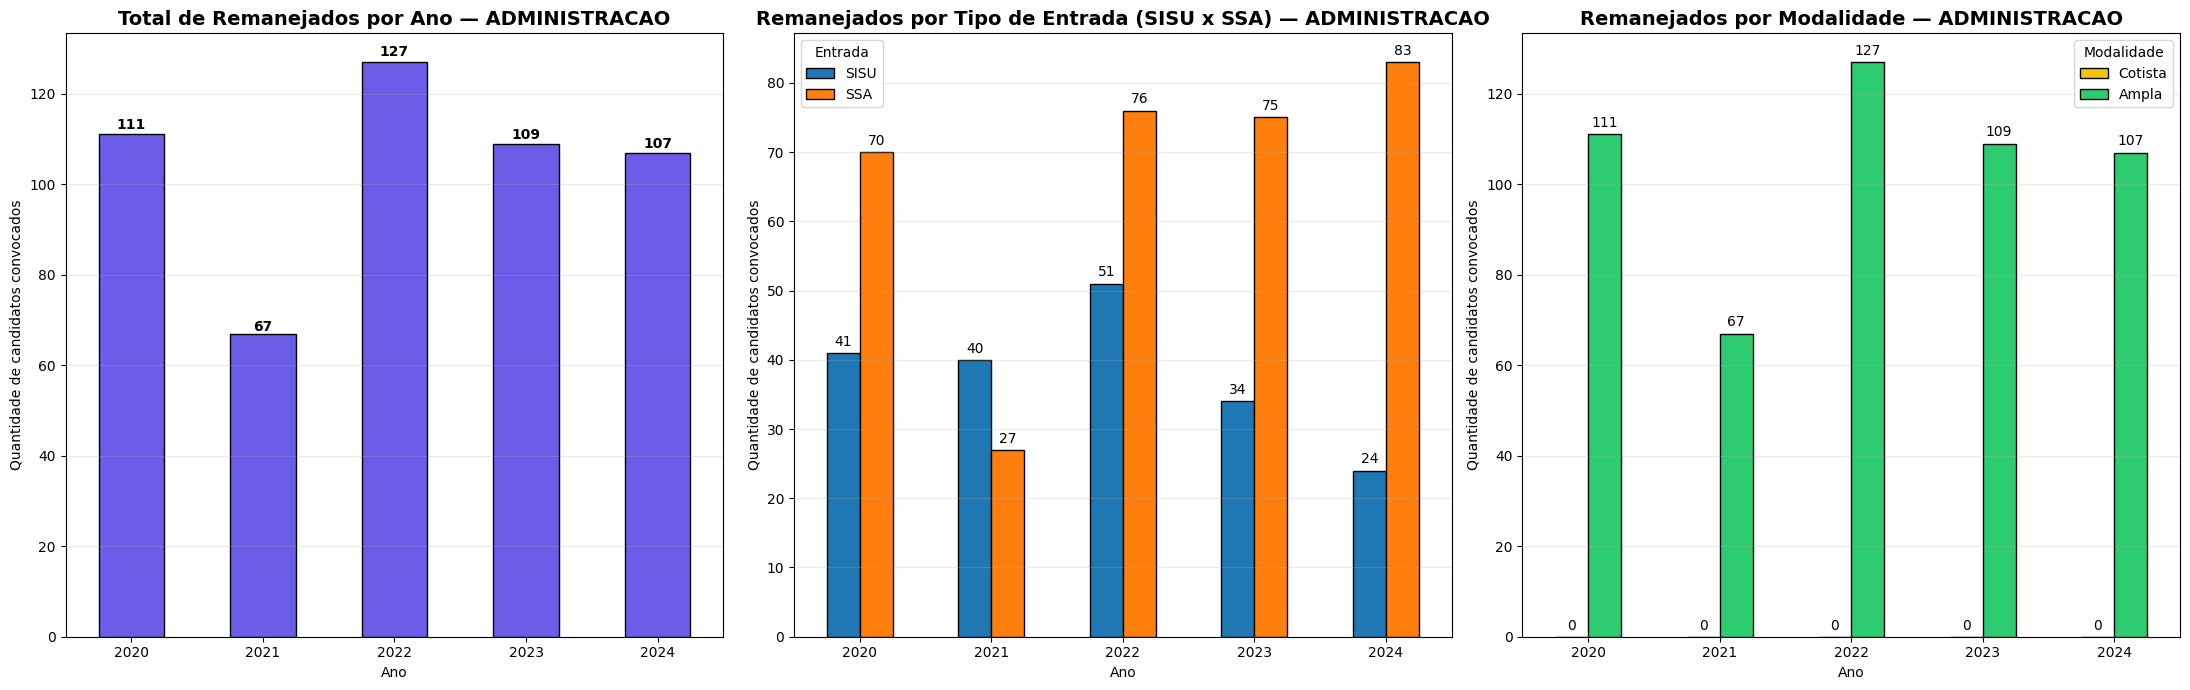

In [ ]:
# Administração:
gerar_graficos_remanejamentos(df, curso="ADMINISTRACAO")


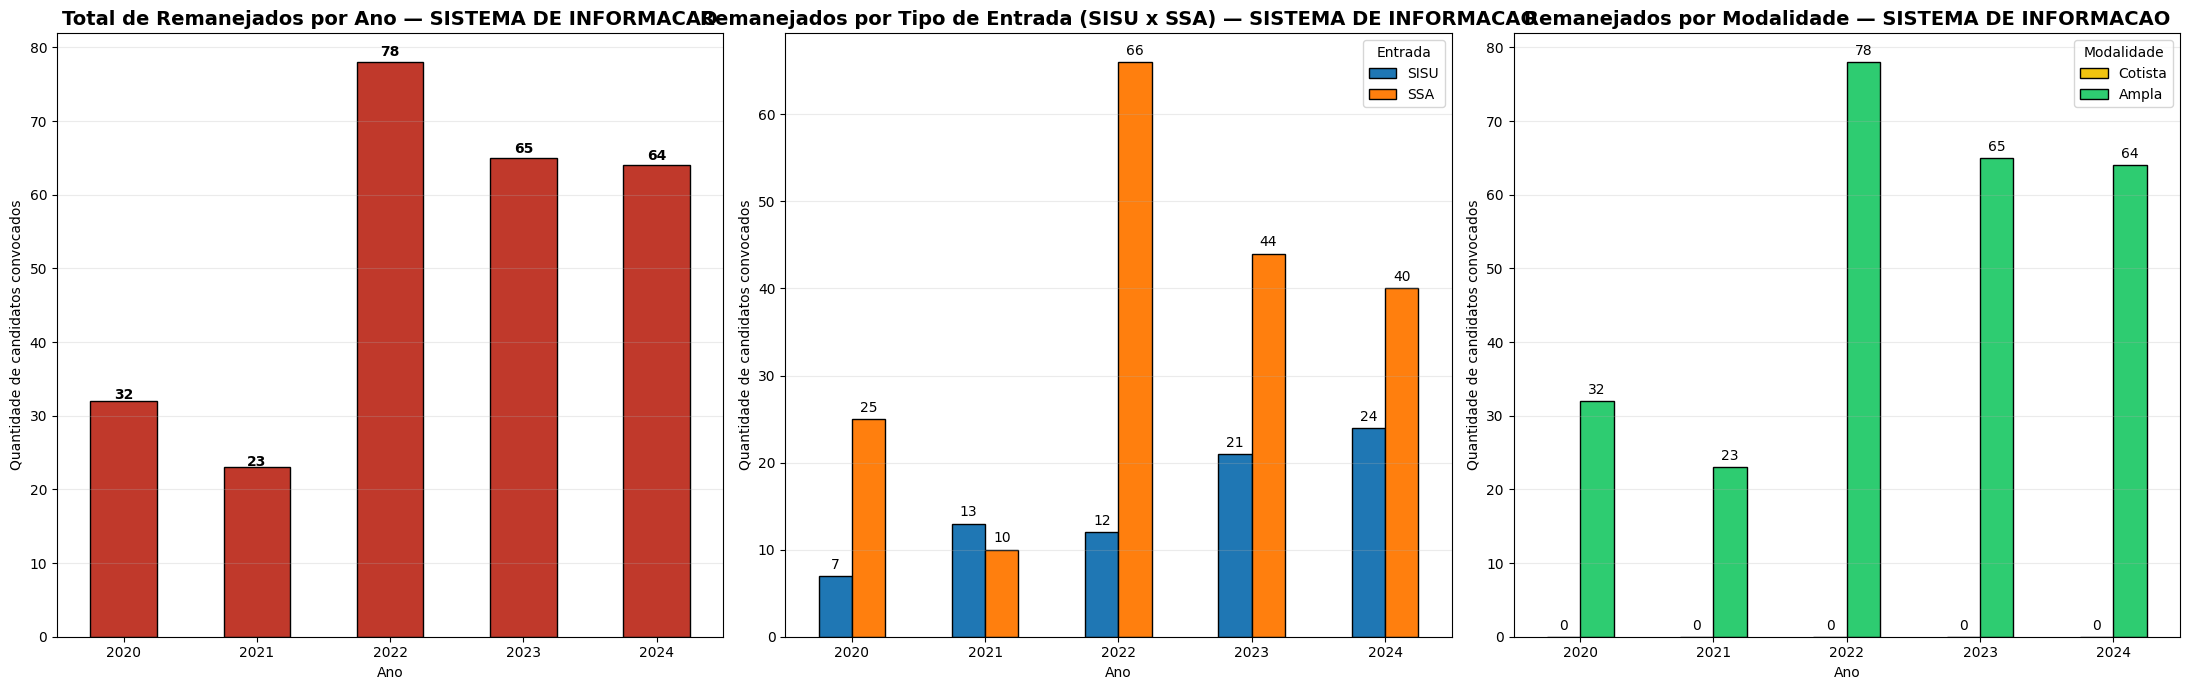

In [ ]:

# Sistema de Informação:
gerar_graficos_remanejamentos(df, curso="SISTEMA DE INFORMACAO")


DESEMPENHO DE NOTAS — ADMINISTRACAO


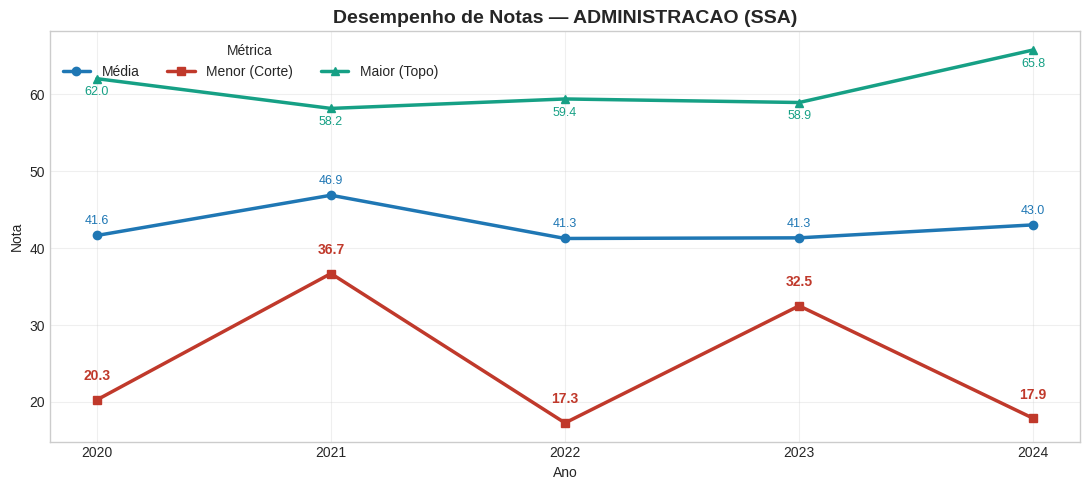

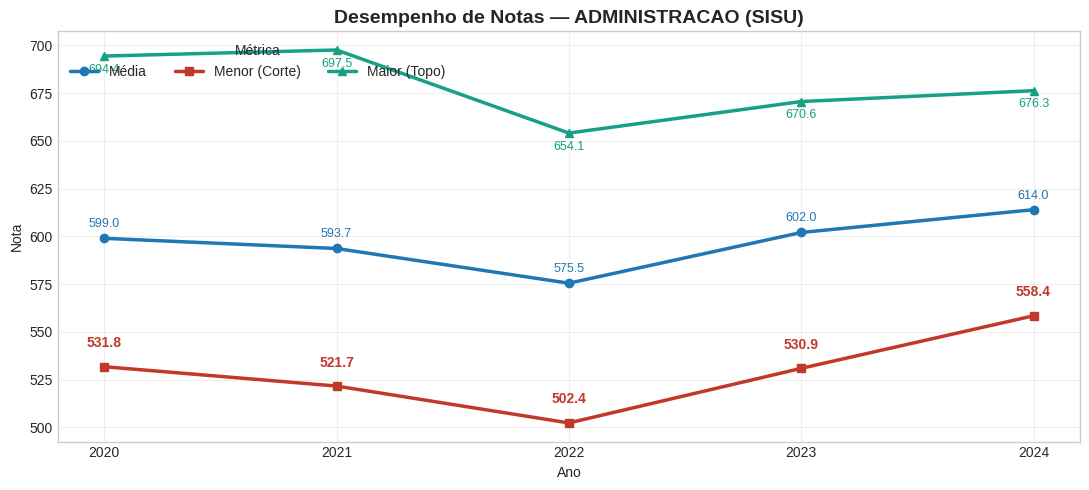


DESEMPENHO DE NOTAS — SISTEMA DE INFORMACAO


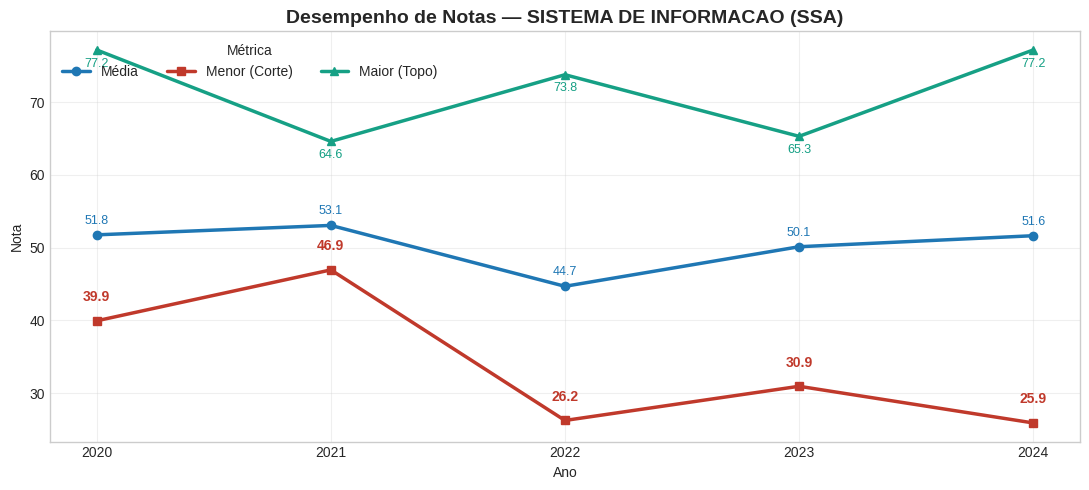

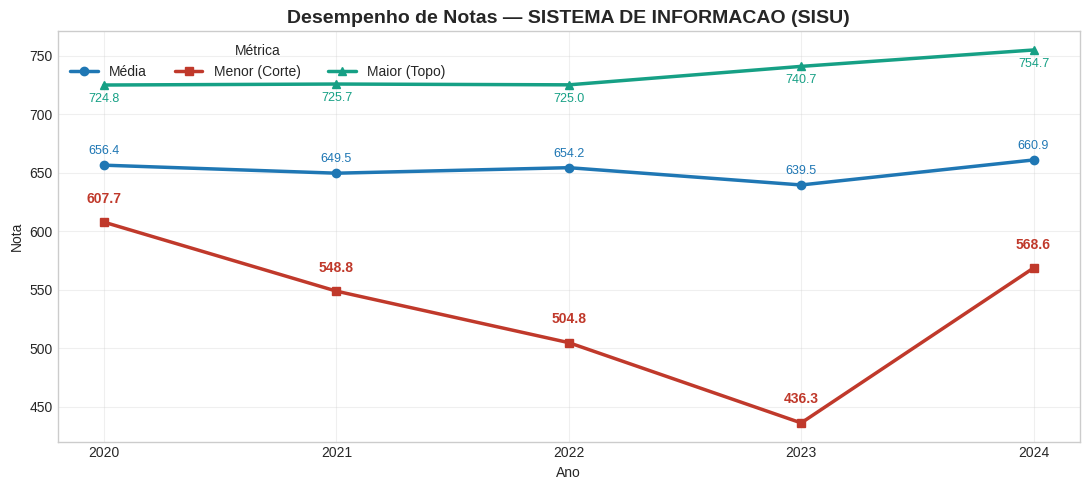

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

CORES_LINHAS = {
    "MEDIA": "#1f77b4",  # azul
    "MIN":   "#c0392b",  # vermelho
    "MAX":   "#16a085",  # teal
}

def gerar_grafico_desempenho_por_entrada(dados):

    df_sel = dados[dados['Status_Resultado'].isin(['CLASSIFICADO', 'REMANEJADOS'])].copy()

    if df_sel.empty:
        print("Atenção: Não foram encontrados dados de candidatos selecionados.")
        return

    df_sel['Curso'] = df_sel['Curso'].astype(str).str.strip().str.upper()
    df_sel['Entrada'] = df_sel['Entrada'].astype(str).str.strip().str.upper()
    df_sel['Ano'] = pd.to_numeric(df_sel['Ano'], errors='coerce').astype(int)
    df_sel['Nota'] = pd.to_numeric(df_sel['Nota'], errors='coerce')

    cursos = sorted(df_sel['Curso'].dropna().unique())

    for curso in cursos:
        df_curso = df_sel[df_sel['Curso'] == curso].copy()
        if df_curso.empty:
            continue

        print(f"\n{'='*45}")
        print(f"DESEMPENHO DE NOTAS — {curso}")
        print(f"{'='*45}")

        entradas = [e for e in ["SSA", "SISU"] if e in df_curso["Entrada"].unique()]

        for entrada in entradas:

            sub = df_curso[df_curso["Entrada"] == entrada].copy()
            if sub.empty:
                continue

            agg = (
                sub.groupby("Ano")["Nota"]
                   .agg(media="mean", minimo="min", maximo="max")
                   .sort_index()
            )

            if agg.empty:
                continue

            fig, ax = plt.subplots(figsize=(11,5))

            # linhas
            ax.plot(agg.index, agg["media"], marker="o", linewidth=2.5,
                    label="Média", color=CORES_LINHAS["MEDIA"])

            ax.plot(agg.index, agg["minimo"], marker="s", linewidth=2.5,
                    label="Menor (Corte)", color=CORES_LINHAS["MIN"])

            ax.plot(agg.index, agg["maximo"], marker="^", linewidth=2.5,
                    label="Maior (Topo)", color=CORES_LINHAS["MAX"])

            # ===== RÓTULOS =====

            # média (um pouco acima)
            for x, y in zip(agg.index, agg["media"]):
                ax.annotate(f"{y:.1f}",
                            xy=(x, y),
                            xytext=(0, 8),
                            textcoords="offset points",
                            ha="center",
                            fontsize=9,
                            color=CORES_LINHAS["MEDIA"])

            # corte (bem acima)
            for x, y in zip(agg.index, agg["minimo"]):
                ax.annotate(f"{y:.1f}",
                            xy=(x, y),
                            xytext=(0, 14),
                            textcoords="offset points",
                            ha="center",
                            fontsize=10,
                            fontweight="bold",
                            color=CORES_LINHAS["MIN"])

            # topo (abaixo do ponto)
            for x, y in zip(agg.index, agg["maximo"]):
                ax.annotate(f"{y:.1f}",
                            xy=(x, y),
                            xytext=(0, -12),
                            textcoords="offset points",
                            ha="center",
                            fontsize=9,
                            color=CORES_LINHAS["MAX"])

            ax.set_title(f"Desempenho de Notas — {curso} ({entrada})",
                         fontsize=14, fontweight="bold")
            ax.set_xlabel("Ano")
            ax.set_ylabel("Nota")
            ax.legend(title="Métrica", ncols=3, loc="upper left")
            ax.grid(True, alpha=0.3)

            ax.set_xticks(list(agg.index))

            plt.tight_layout()
            plt.show()

# EXECUÇÃO
gerar_grafico_desempenho_por_entrada(df)


RESUMO DE DADOS: CANDIDATOS NÃO CHAMADOS (GERAL)
Total de Remanejáveis (Lista de Espera base): 2052
Total de Remanejados (Que foram convocados):  783
Total Final de NÃO CHAMADOS:                  1269
--------------------------------------------------
Detalhamento de Não Chamados por Ano:
Ano 2020: 204 candidatos
Ano 2021: 320 candidatos
Ano 2022: 216 candidatos
Ano 2023: 230 candidatos
Ano 2024: 299 candidatos


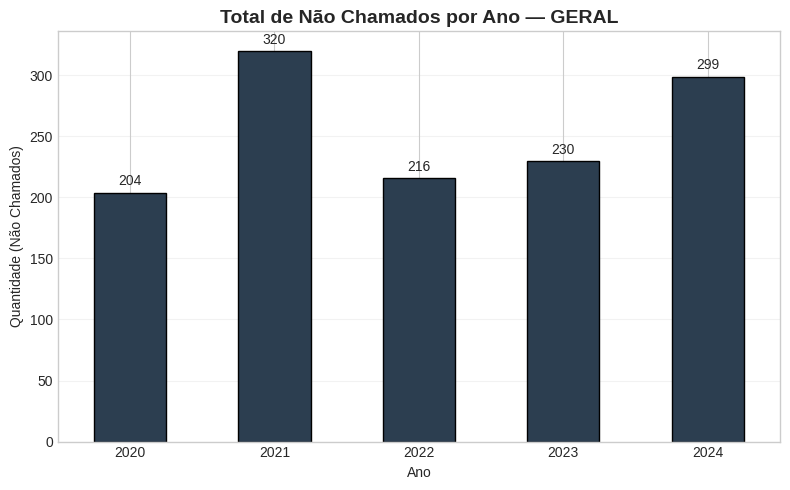

RESUMO DE DADOS: NÃO CHAMADOS POR ENTRADA (SISU x SSA)
Entrada  SISU  SSA
Ano               
2020      134   70
2021      171  149
2022      150   66
2023      101  129
2024      176  123


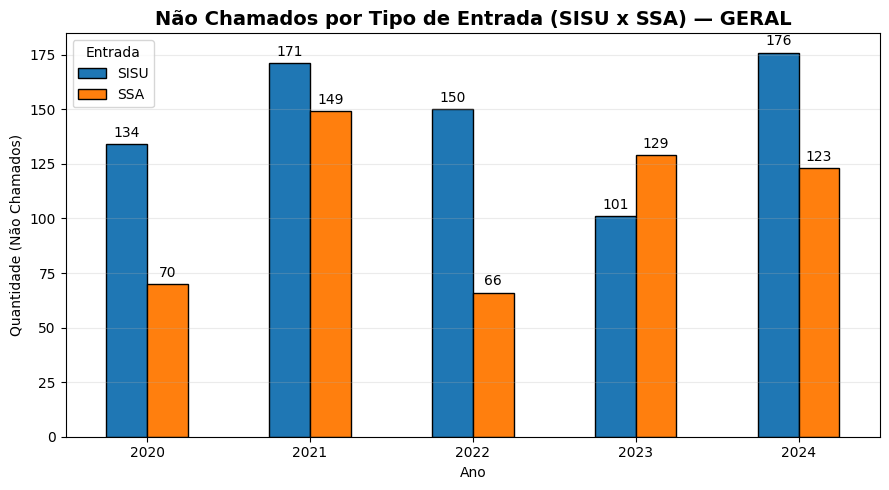


CANDIDATOS NÃO CHAMADOS - GERAL


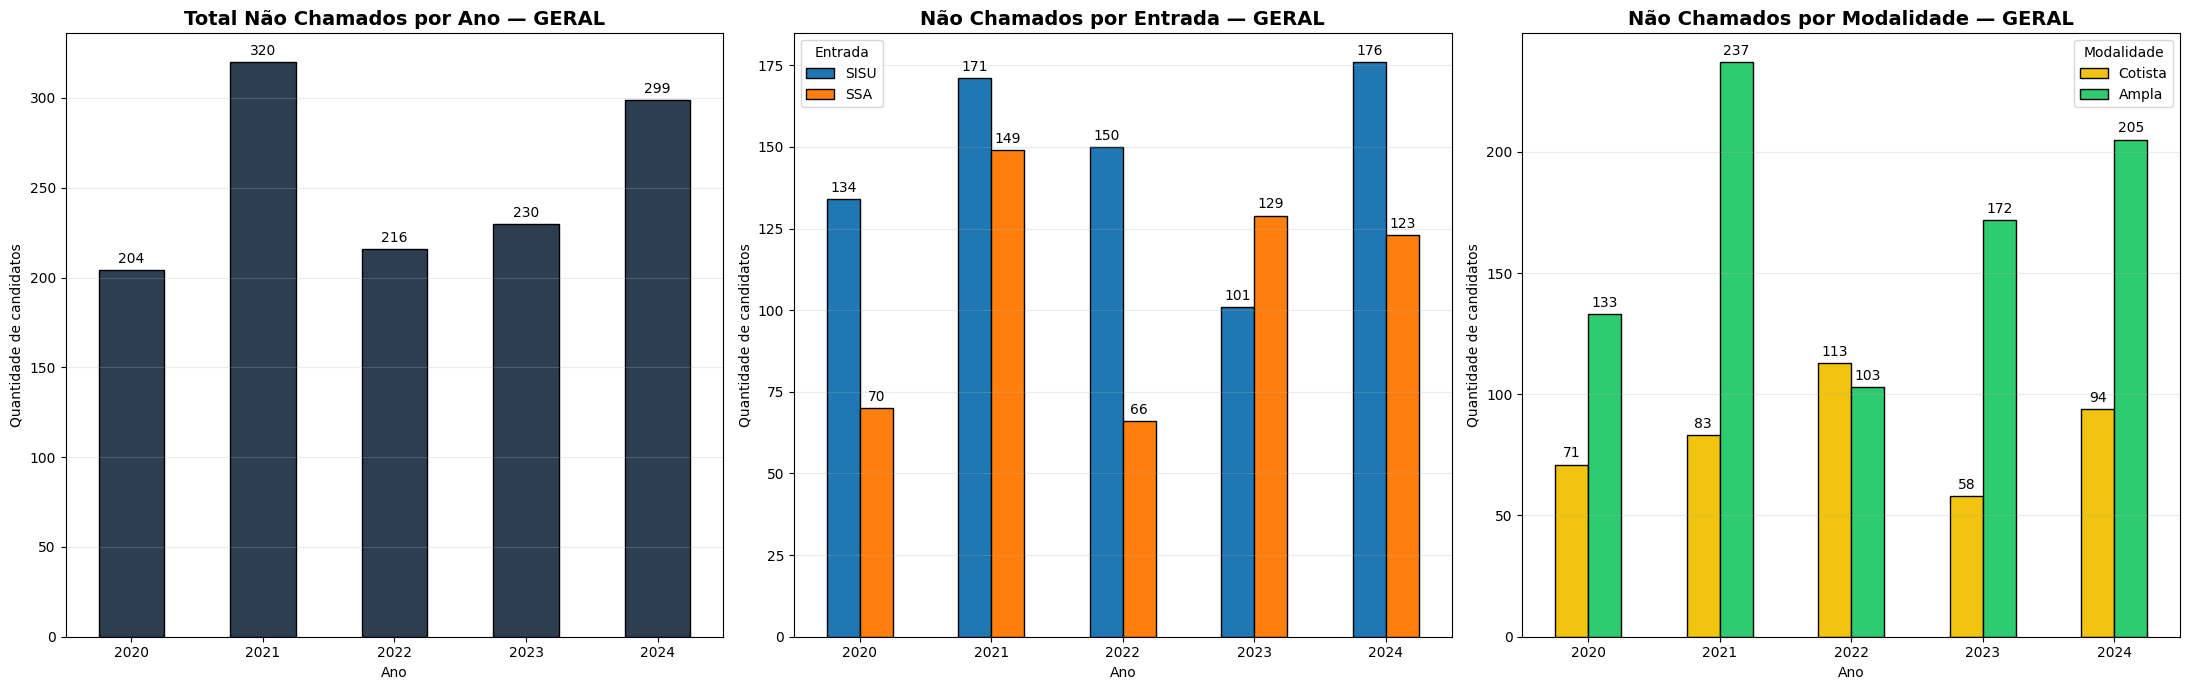


CANDIDATOS NÃO CHAMADOS - ADMINISTRAÇÃO


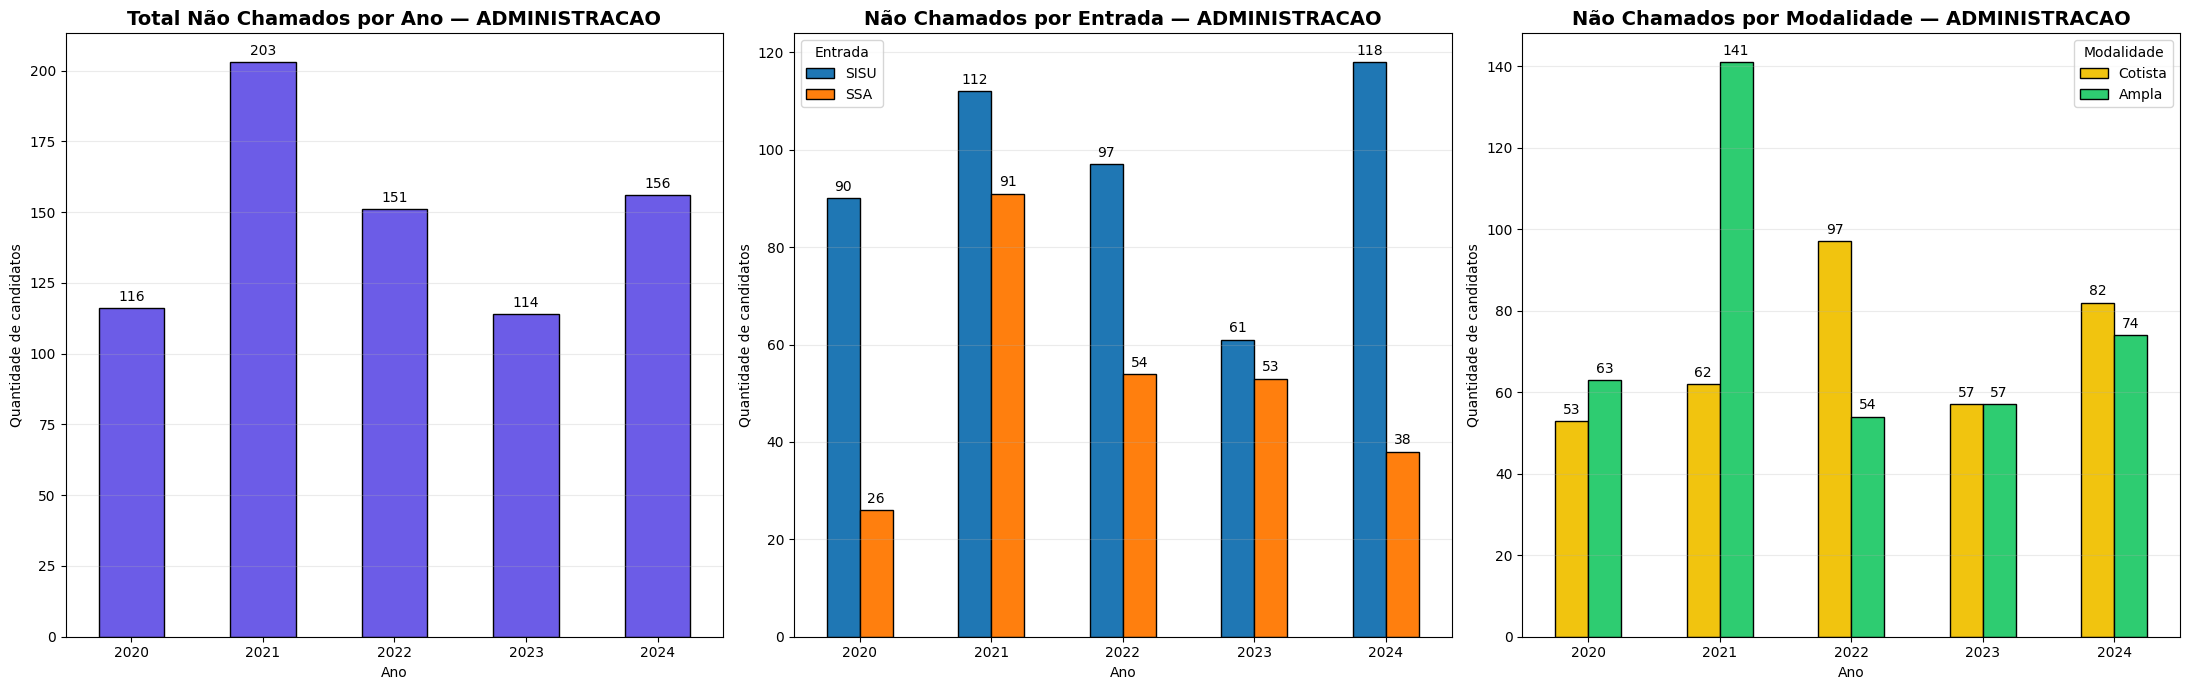


CANDIDATOS NÃO CHAMADOS - SISTEMA DE INFORMAÇÃO


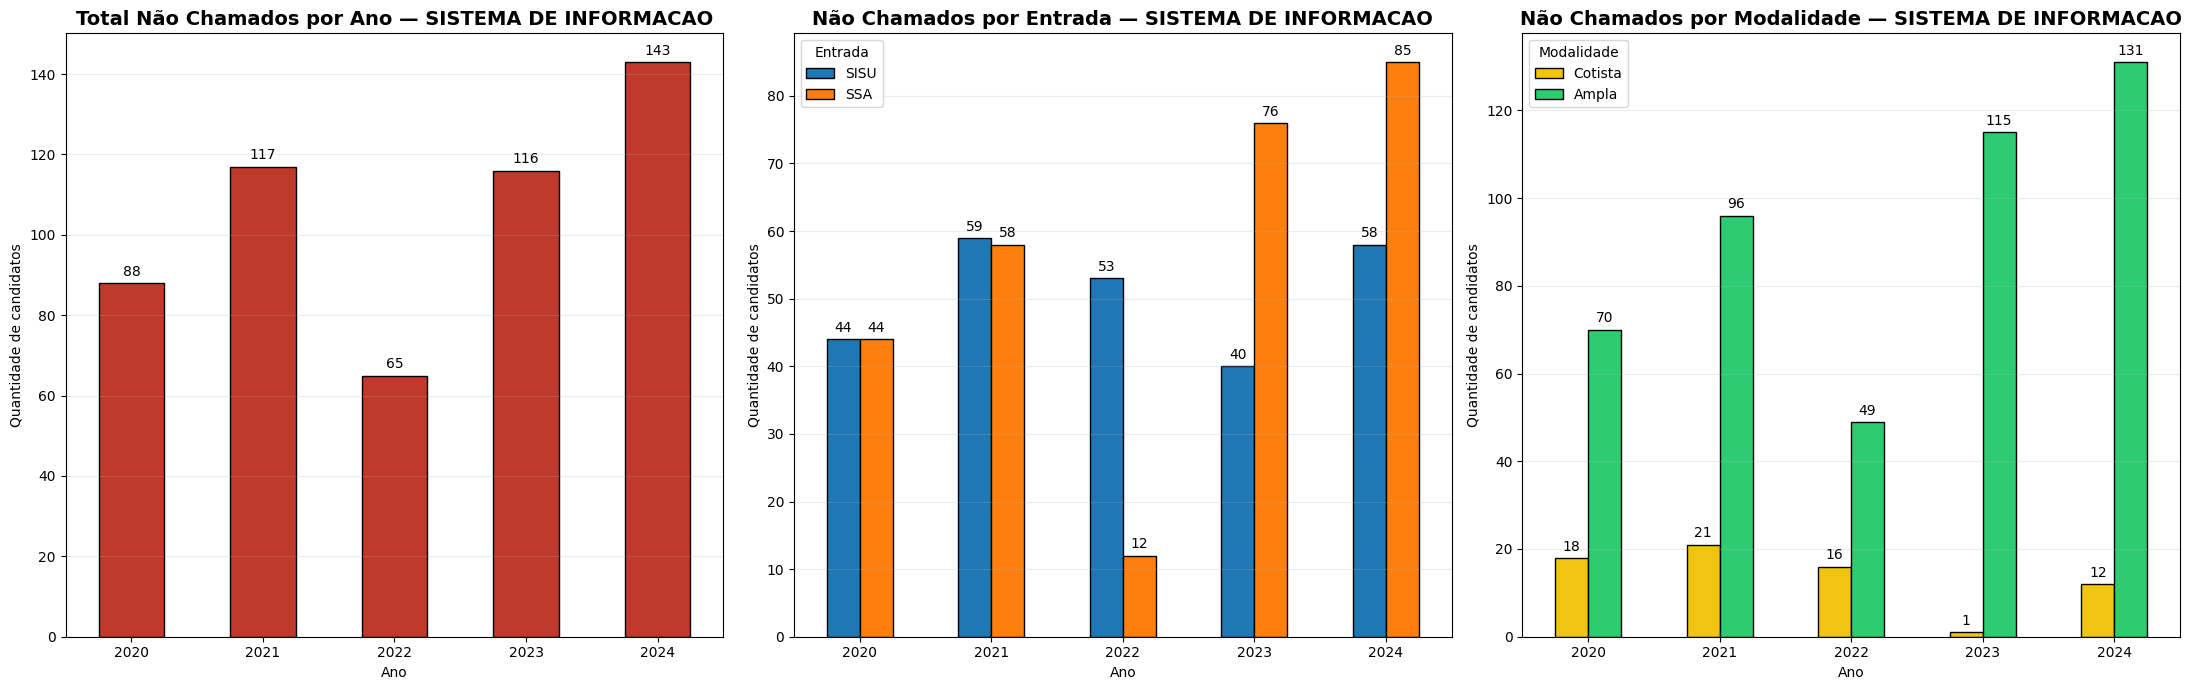

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CORES FIXAS (Padrão mantido)
# =========================
CORES_ENTRADA = {"SISU": "#1f77b4", "SSA": "#ff7f0e"}  # azul / laranja
CORES_MODAL = {"Ampla": "#2ecc71", "Cotista": "#f1c40f"}  # verde / amarelo

# Cor do gráfico TOTAL muda por contexto (Geral/ADM/SI)
CORES_CONTEXTO = {
    "GERAL": "#2c3e50",                  # azul petróleo
    "ADMINISTRACAO": "#6c5ce7",
    "SISTEMA DE INFORMACAO": "#c0392b",  # vermelho
}

def gerar_graficos_nao_chamados(dados, curso=None):
    """
    Gera 3 gráficos (Total, Entrada, Modalidade) para candidatos
    que eram REMANEJÁVEIS mas NÃO FORAM CHAMADOS.
    Lógica: (Qtd REMANEJÁVEIS) - (Qtd REMANEJADOS)
    """
    df = dados.copy()

    # Padronizações de segurança (com a correção da Categoria_Modalidade)
    df.columns = df.columns.str.strip()
    df["Status_Resultado"] = df["Status_Resultado"].astype(str).str.strip().str.upper()
    df["Entrada"] = df["Entrada"].astype(str).str.strip().str.upper()
    df["Curso"] = df["Curso"].astype(str).str.strip().str.upper()
    df["Categoria_Modalidade"] = df["Categoria_Modalidade"].astype(str).str.strip().str.upper()
    df["Ano"] = pd.to_numeric(df["Ano"], errors="coerce").fillna(0).astype(int)

    # Criar Modalidade Simples (Ampla x Cotista)
    df['Modalidade_Simples'] = df['Categoria_Modalidade'].apply(
        lambda x: 'Cotista' if 'COTISTA' in str(x) else 'Ampla'
    )

    # Definir o rótulo do curso (Contexto)
    rotulo = "GERAL" if curso is None else str(curso).strip().upper()

    # Filtrar por curso, se solicitado
    if curso is not None:
        df = df[df["Curso"] == rotulo].copy()

    # Separar as bases
    df_remanejaveis = df[df["Status_Resultado"] == "REMANEJÁVEL"]
    df_chamados = df[df["Status_Resultado"] == "REMANEJADOS"]

    if df_remanejaveis.empty:
        print(f"Atenção: Não foram encontrados dados para {rotulo}.")
        return

    cor_contexto = CORES_CONTEXTO.get(rotulo, CORES_CONTEXTO["GERAL"])

    # Criar figura com 3 subplots lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    # =========================
    # GRÁFICO 1: TOTAL POR ANO
    # =========================
    tot_rem = df_remanejaveis.groupby("Ano").size()
    tot_chamados = df_chamados.groupby("Ano").size()

    nao_chamados_ano = tot_rem.subtract(tot_chamados, fill_value=0).clip(lower=0).astype(int)

    nao_chamados_ano.plot(kind="bar", ax=axes[0], color=cor_contexto, edgecolor="black")
    axes[0].set_title(f"Total Não Chamados por Ano — {rotulo}", fontsize=14, fontweight="bold")
    axes[0].set_ylabel("Quantidade de candidatos")
    axes[0].set_xlabel("Ano")
    for container in axes[0].containers:
        axes[0].bar_label(container, padding=3)
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].tick_params(axis="x", rotation=0)

    # =========================
    # GRÁFICO 2: POR ENTRADA (SISU x SSA)
    # =========================
    ent_rem = df_remanejaveis.groupby(["Ano", "Entrada"]).size()
    ent_chamados = df_chamados.groupby(["Ano", "Entrada"]).size()

    nao_chamados_ent = ent_rem.subtract(ent_chamados, fill_value=0).clip(lower=0).astype(int)
    tabela_entrada = nao_chamados_ent.unstack(fill_value=0).sort_index()

    cols = [c for c in ["SISU", "SSA"] if c in tabela_entrada.columns] + \
           [c for c in tabela_entrada.columns if c not in ["SISU", "SSA"]]
    tabela_entrada = tabela_entrada[cols]

    tabela_entrada.plot(
        kind="bar",
        ax=axes[1],
        color=[CORES_ENTRADA.get(c, "#7f7f7f") for c in tabela_entrada.columns],
        edgecolor="black"
    )
    axes[1].set_title(f"Não Chamados por Entrada — {rotulo}", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Ano")
    axes[1].set_ylabel("Quantidade de candidatos")
    axes[1].legend(title="Entrada")
    for container in axes[1].containers:
        axes[1].bar_label(container, padding=3)
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].tick_params(axis="x", rotation=0)

    # =========================
    # GRÁFICO 3: MODALIDADE (Ampla x Cotista)
    # =========================
    mod_rem = df_remanejaveis.groupby(["Ano", "Modalidade_Simples"]).size()
    mod_chamados = df_chamados.groupby(["Ano", "Modalidade_Simples"]).size()

    nao_chamados_mod = mod_rem.subtract(mod_chamados, fill_value=0).clip(lower=0).astype(int)
    base_mod = nao_chamados_mod.unstack(fill_value=0).sort_index()

    for col in ["Cotista", "Ampla"]:
        if col not in base_mod.columns:
            base_mod[col] = 0

    tabela_mod = base_mod[["Cotista", "Ampla"]]

    cores_mod = {
        "Cotista": CORES_MODAL["Cotista"],     # amarelo
        "Ampla": CORES_MODAL["Ampla"],         # verde
    }

    tabela_mod.plot(
        kind="bar",
        ax=axes[2],
        color=[cores_mod[c] for c in tabela_mod.columns],
        edgecolor="black"
    )

    axes[2].set_title(f"Não Chamados por Modalidade — {rotulo}", fontsize=14, fontweight="bold")
    axes[2].set_xlabel("Ano")
    axes[2].set_ylabel("Quantidade de candidatos")
    axes[2].legend(title="Modalidade")
    for container in axes[2].containers:
        axes[2].bar_label(container, padding=3)
    axes[2].grid(axis="y", alpha=0.25)
    axes[2].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

# =========================
# COMO RODAR E TESTAR
# =========================

print("\n" + "="*50 + "\nCANDIDATOS NÃO CHAMADOS - GERAL\n" + "="*50)
gerar_graficos_nao_chamados(df)

print("\n" + "="*50 + "\nCANDIDATOS NÃO CHAMADOS - ADMINISTRAÇÃO\n" + "="*50)
gerar_graficos_nao_chamados(df, curso="ADMINISTRACAO")

print("\n" + "="*50 + "\nCANDIDATOS NÃO CHAMADOS - SISTEMA DE INFORMAÇÃO\n" + "="*50)
gerar_graficos_nao_chamados(df, curso="SISTEMA DE INFORMACAO")

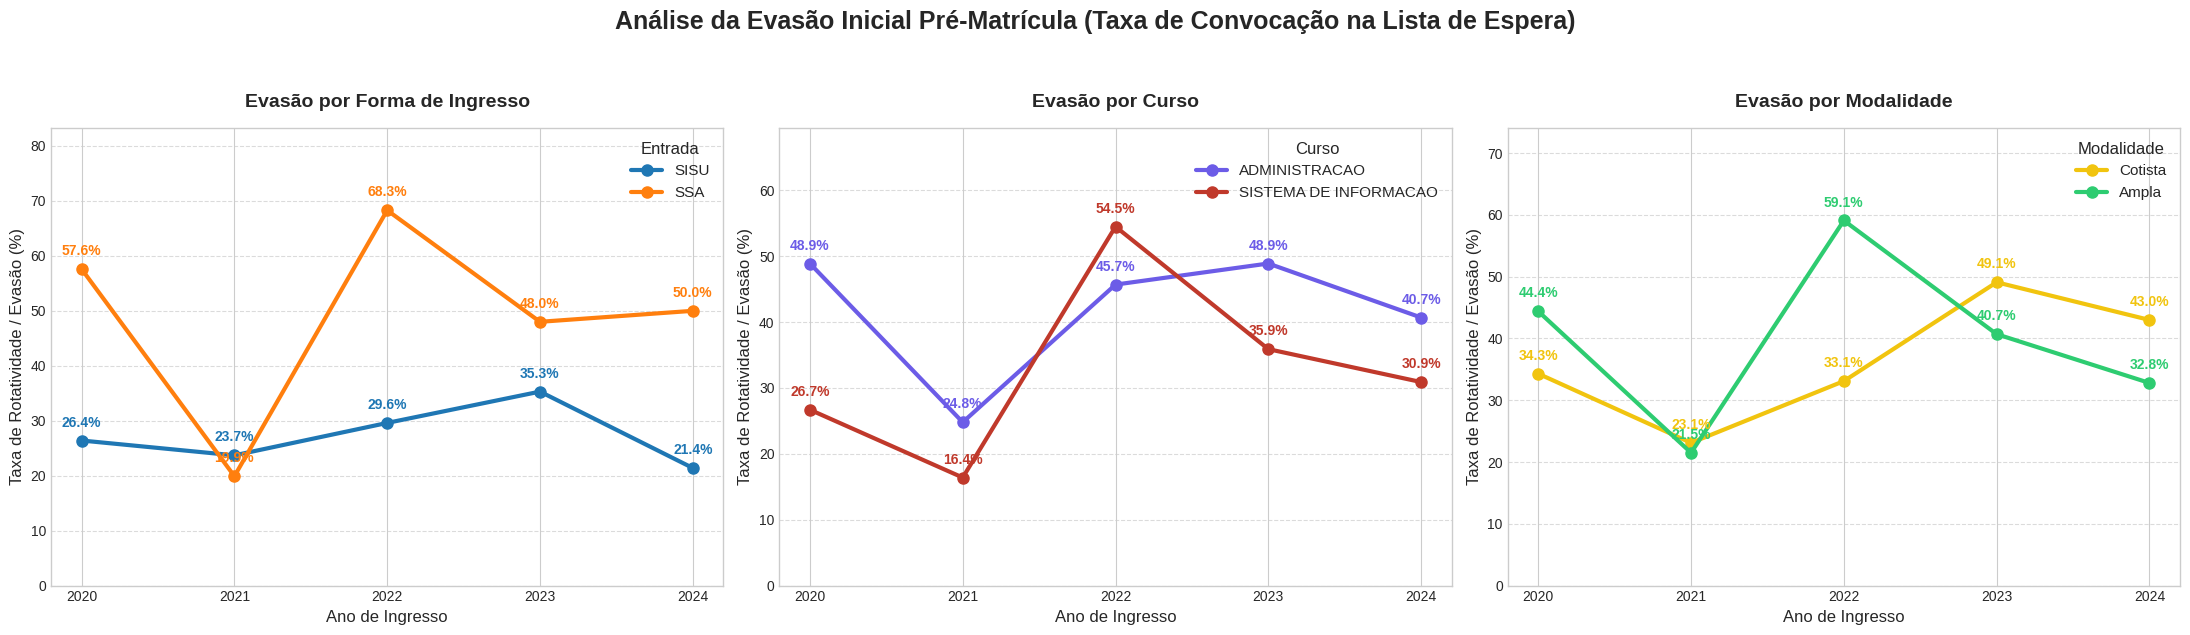

TABELA RESUMO DAS TAXAS DE EVASÃO (%) PARA O ARTIGO

--- Por Forma de Ingresso (SISU vs SSA) ---
Entrada  SISU   SSA
Ano                
2020     26.4  57.6
2021     23.7  19.9
2022     29.6  68.3
2023     35.3  48.0
2024     21.4  50.0

--- Por Curso ---
Curso  ADMINISTRACAO  SISTEMA DE INFORMACAO
Ano                                        
2020            48.9                   26.7
2021            24.8                   16.4
2022            45.7                   54.5
2023            48.9                   35.9
2024            40.7                   30.9

--- Por Modalidade ---
Modalidade_Simples  Cotista  Ampla
Ano                               
2020                   34.3   44.4
2021                   23.1   21.5
2022                   33.1   59.1
2023                   49.1   40.7
2024                   43.0   32.8


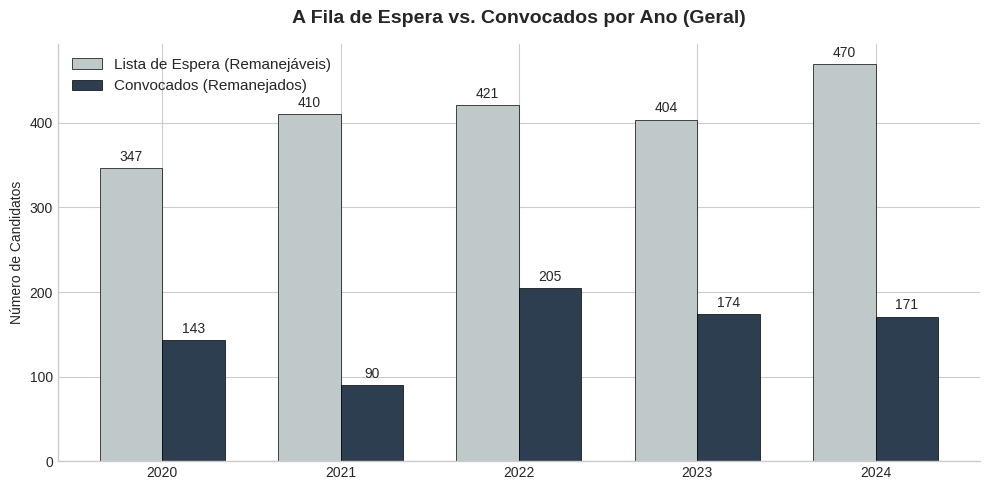

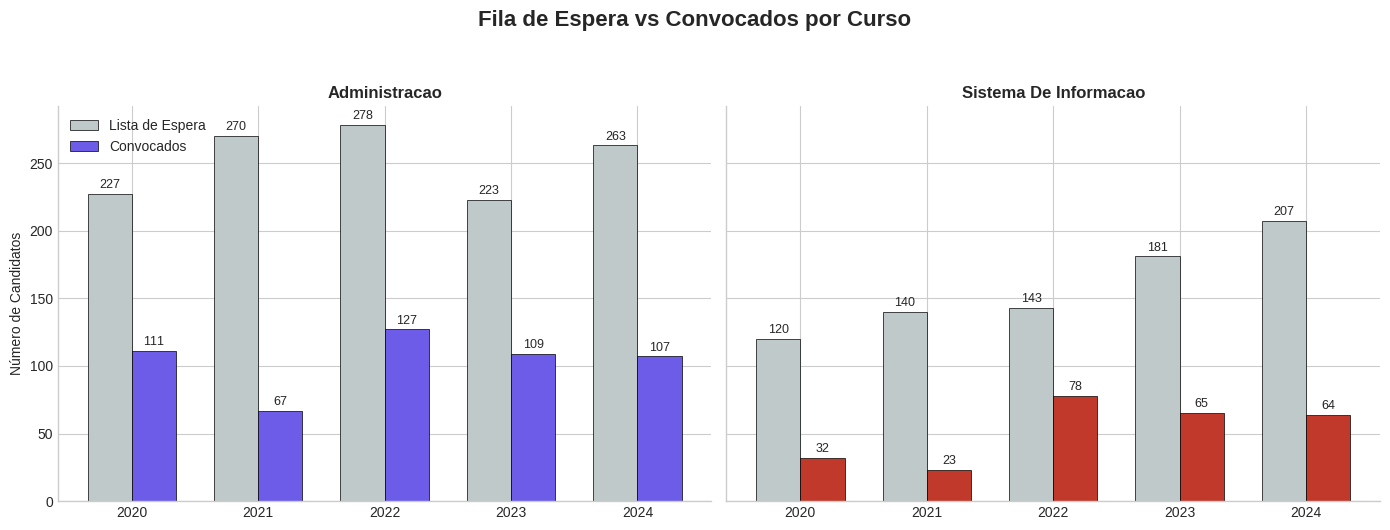

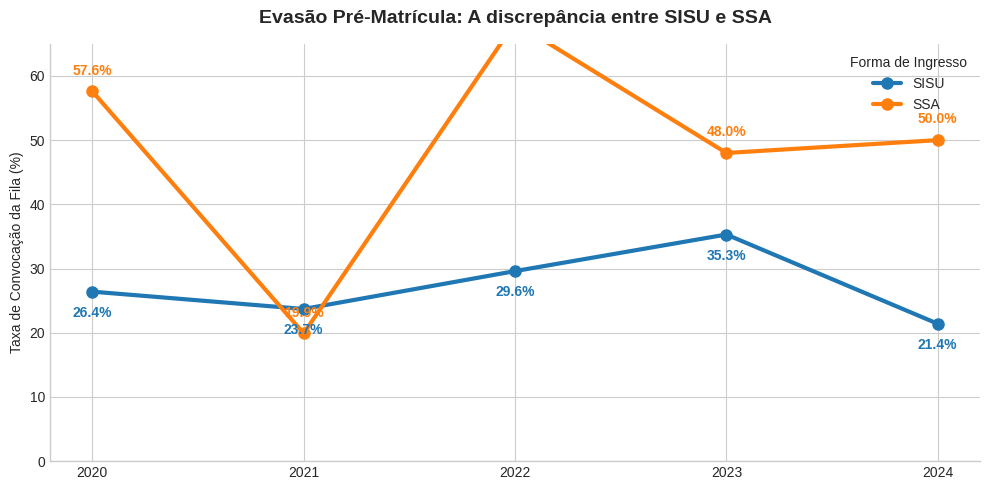

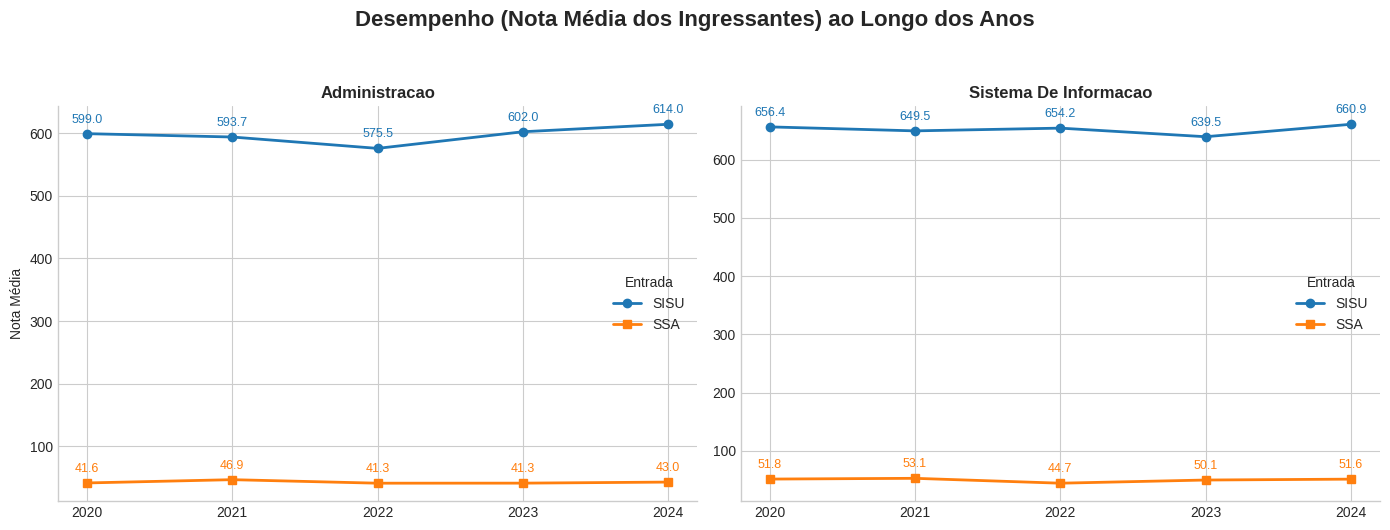

Costurando a narrativa e gerando o PDF final...
Sucesso! Relatório consolidado e pronto para uso: analise do remantejamento


FileNotFoundError: Cannot find file: analise do remantejamento